# IEA - SISEPUEDE Energy Crosswalk — Comparison Notebook

This notebook is a **walkthrough** of `sisepuede/calibration/iea_crosswalk.py`.
All the real logic lives in that module; here we just call it step-by-step
so you can see what each piece does.

**Steps:**
1. Setup — imports, paths
2. Run SISEPUEDE energy model
3. Build an `IEACrosswalk` object (loads the mapping CSV)
4. Aggregate SISEPUEDE outputs using the crosswalk
5. Load and normalise IEA data
6. Build the comparison table
7. Summarise and visualise

---
## 0. Setup

We import the SISEPUEDE file structure (gives us model attributes and
the path to the ref directory) and our new `IEACrosswalk` class.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
# Add the sisepuede repo root so local edits take precedence over the installed package
path = "/Users/dianamendez/sisepuede"
if path not in sys.path:
    sys.path.insert(0, path)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sisepuede.manager.sisepuede_file_structure import SISEPUEDEFileStructure
from sisepuede.calibration.iea_crosswalk import IEACrosswalk
from sisepuede.calibration.iea_data_loader import IEADataLoader

# ── Paths — change these ─────────────────────────────────────────────────────
PATH_SISEPUEDE_INPUT = "/Users/dianamendez/Documents/sisepuede/sisepuede_raw_inputs_latest_LBY_modified_march_2026.csv"
PATH_IEA_DATA_DIR    = "/Users/dianamendez/data_collection_temporary"  # root of IEA CSV repo
ISO_COUNTRY          = "LBY"
START_YEAR           = 2015 # year from where to start comparison
TRUE_DATA_LIMIT_YEAR = 2023 # last year of true data. the rest are projections
PATH_CROSSWALK_FILE  = "/Users/dianamendez/sisepuede/sisepuede/ref/data_crosswalks/sisepuede_iea_energy_crosswalk.csv"
# ─────────────────────────────────────────────────────────────────────────────
# Run this notebook with the sisepuede-env kernel:
#   /Users/dianamendez/sisepuede-env/bin/python

file_struct      = SISEPUEDEFileStructure()
model_attributes = file_struct.model_attributes

---
## 1. Run SISEPUEDE — get energy outputs

`EnergyConsumption` depends on `AFOLU` and `IPPU`, so we run those first
and merge their outputs in before calling the energy model.

In [2]:
from sisepuede.models.afolu import AFOLU
from sisepuede.models.energy_consumption import EnergyConsumption
from sisepuede.models.ippu import IPPU

model_afolu     = AFOLU            (model_attributes)
model_ippu      = IPPU             (model_attributes)
model_energycon = EnergyConsumption(model_attributes)

df_input = pd.read_csv(PATH_SISEPUEDE_INPUT)

# Only use truth available data for comparison
true_data_condition = df_input["year"] <= TRUE_DATA_LIMIT_YEAR
df_input = df_input.loc[true_data_condition]
print(f"Input shape: {df_input.shape}")
display(df_input)

# Run dependency models first, then merge their outputs as additional inputs
df_out_afolu = model_afolu(df_input)
df_out_ippu  = model_ippu (df_input)

df_input_energy = df_input.merge(df_out_afolu, how="left").merge(df_out_ippu, how="left")
df_out_energycon = model_energycon(df_input_energy)

print(f"Output shape: {df_out_energycon.shape}")
display(df_out_energycon)

Input shape: (9, 2420)


,year,ef_ippu_tonne_nf3_per_tonne_production_chemicals,ef_ippu_tonne_nf3_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing,ef_ippu_tonne_sf6_per_tonne_production_chemicals,ef_ippu_tonne_sf6_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_tonne_production_metals,frac_agrc_bevs_and_spices_cl2_dry,frac_agrc_cereals_cl2_dry,frac_agrc_fibers_cl2_dry,...,nemomod_entc_scalar_availability_factor_pp_nuclear,nemomod_entc_scalar_availability_factor_pp_ocean,nemomod_entc_scalar_availability_factor_pp_oil,nemomod_entc_scalar_availability_factor_pp_solar,nemomod_entc_scalar_availability_factor_pp_waste_incineration,nemomod_entc_scalar_availability_factor_pp_wind,iso_alpha_3,population_gnrl_rural,population_gnrl_urban,gdp_mmm_usd
0,2015,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,795843.0,5735976.0,116.940831
1,2016,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,808058.0,5824068.0,112.487607
2,2017,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,821006.0,5917764.0,121.473195
3,2018,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,834319.0,6014736.0,129.305468
4,2019,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,846496.0,6104537.0,112.565781
5,2020,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,857578.0,6187821.0,77.180930
6,2021,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,867887.0,6267288.0,90.199384
7,2022,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,877793.0,6346012.0,88.610007
8,2023,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,886562.0,6419097.0,101.162039


Output shape: (9, 480)


,time_period,dem_trde_freight_mt_km,dem_trde_private_and_public_passenger_km,dem_trde_regional_passenger_km,emission_co2e_ch4_ccsq_direct_air_capture,emission_co2e_ch4_inen_agriculture_and_livestock,emission_co2e_ch4_inen_cement,emission_co2e_ch4_inen_chemicals,emission_co2e_ch4_inen_electronics,emission_co2e_ch4_inen_glass,...,vehicle_distance_traveled_trns_road_light_diesel,vehicle_distance_traveled_trns_road_light_electricity,vehicle_distance_traveled_trns_road_light_gasoline,vehicle_distance_traveled_trns_road_light_hydrocarbon_gas_liquids,vehicle_distance_traveled_trns_road_light_hydrogen,vehicle_distance_traveled_trns_water_borne,vehicle_distance_traveled_trns_water_borne_diesel,vehicle_distance_traveled_trns_water_borne_electricity,vehicle_distance_traveled_trns_water_borne_hydrogen,vehicle_distance_traveled_trns_water_borne_natural_gas
0,0,243207.015073,8.229379e+10,7.208654e+09,0.0,0.005427,0.000594,0.001823,0.000003,0.000396,...,9.634908e+09,3.757308e+08,1.236291e+10,0.0,0.0,4.868815e+06,4.868815e+06,0.0,0.0,0.0
1,1,235797.760528,8.003948e+10,7.011184e+09,0.0,0.005500,0.000604,0.001718,0.000003,0.000403,...,9.349937e+09,3.641232e+08,1.205135e+10,0.0,0.0,4.759688e+06,4.759688e+06,0.0,0.0,0.0
2,2,250866.311483,8.541177e+10,7.481779e+09,0.0,0.010420,0.000603,0.001695,0.000003,0.000402,...,9.956474e+09,3.872135e+08,1.288730e+10,0.0,0.0,5.050586e+06,5.050586e+06,0.0,0.0,0.0
3,3,263806.473089,9.009704e+10,7.892192e+09,0.0,0.013650,0.000607,0.001738,0.000003,0.000405,...,1.048110e+10,4.070839e+08,1.362173e+10,0.0,0.0,5.352734e+06,5.352734e+06,0.0,0.0,0.0
4,4,236484.888598,8.103428e+10,7.098325e+09,0.0,0.014537,0.000619,0.001807,0.000003,0.000413,...,9.407156e+09,3.649396e+08,1.227638e+10,0.0,0.0,4.828262e+06,4.828262e+06,0.0,0.0,0.0
5,5,177014.009669,6.087591e+10,5.332522e+09,0.0,0.016184,0.000684,0.001858,0.000003,0.000456,...,7.051476e+09,2.732793e+08,9.241804e+09,0.0,0.0,3.546520e+06,3.546520e+06,0.0,0.0,0.0
6,6,200900.208277,6.924563e+10,6.065680e+09,0.0,0.017463,0.000693,0.001884,0.000003,0.000462,...,7.957356e+09,3.010306e+08,1.062198e+10,0.0,0.0,3.798449e+06,3.798449e+06,0.0,0.0,0.0
7,7,198068.204507,6.844153e+10,5.995244e+09,0.0,0.018395,0.000687,0.001866,0.000003,0.000458,...,7.758072e+09,2.879362e+08,1.065561e+10,0.0,0.0,3.745757e+06,3.745757e+06,0.0,0.0,0.0
8,8,220514.052199,7.635269e+10,6.688234e+09,0.0,0.019125,0.000689,0.001872,0.000003,0.000459,...,8.700409e+09,3.169802e+08,1.226976e+10,0.0,0.0,4.171009e+06,4.171009e+06,0.0,0.0,0.0


In [3]:
# SISEPUEDE outputs use integer time_period (0, 1, 2 ...) but IEA uses
# calendar years.  We build a time_period -> year map from the input file
# and add the year column to the output.

df_tp_year = (
    df_input[["year"]]
    .reset_index(drop=True)
    .reset_index()           # creates 'index' column = time_period
    .rename(columns={"index": "time_period"})
)

df_out_energycon = df_out_energycon.merge(df_tp_year, on="time_period", how="left")
df_out_energycon[["time_period", "year"]].head()

print(f"Output dataframe shape: {df_out_energycon.shape}")

Output dataframe shape: (9, 481)


---
## 2. Build the `IEACrosswalk` object

`IEACrosswalk.__init__()` does two things:
- Stores a reference to `SISEPUEDERegions`, which holds IEA field name
  constants (`Balance`, `Country`, `Product`, `Time`, `Unit`, `Value`) and
  the country-name cleaning utilities.
- Reads and cleans `ref/data_crosswalks/sisepuede_iea_energy_crosswalk.csv`,
  dropping blank separator rows and `no_match` entries.

In [4]:
from sisepuede.calibration.build_iea_energy_crosswalk import IEACrosswalkBuilder

# #Do this if creating or updating the crosswalk
builder = IEACrosswalkBuilder(model_attributes, PATH_CROSSWALK_FILE)
df_xw = builder.build(write_csv=True)

xw = IEACrosswalk(model_attributes, path_crosswalk = PATH_CROSSWALK_FILE)

print(f"Crosswalk loaded: {len(xw.df_crosswalk)} mappable entries")
print("IEA field names:",
      xw.field_balance, xw.field_country,
      xw.field_product, xw.field_time,
      xw.field_unit, xw.field_value)

# Preview the crosswalk table
xw.df_crosswalk[["iea_balance_code", "iea_product_code",
                  "sisepuede_subsector", "aggregation",
                  "unit_conversion_to_tj", "mapping_quality"]].head(10)

IEA crosswalk written to: /Users/dianamendez/sisepuede/sisepuede/ref/data_crosswalks/sisepuede_iea_energy_crosswalk.csv
Crosswalk loaded: 64 mappable entries
IEA field names: Balance Country Product Time Unit Value


,iea_balance_code,iea_product_code,sisepuede_subsector,aggregation,unit_conversion_to_tj,mapping_quality
0,INDPROD,COAL,enfu,direct,1000.0,approximate
1,INDPROD,NATGAS,enfu,direct,1000.0,exact
2,INDPROD,OIL,enfu,sum,1000.0,approximate
3,INDPROD,ELECT,enfu,direct,1000.0,exact
4,IMPORTS,IMPORTS,enfu,sum,1000.0,approximate
5,EXPORTS,EXPORTS,enfu,sum,1000.0,approximate
6,COALIMPORTS,IMPORTS,enfu,direct,1000.0,exact
7,COALEXPORTS,EXPORTS,enfu,direct,1000.0,exact
8,OILIMPORTS,IMPORTS,enfu,sum,1000.0,approximate
9,OILEXPORTS,EXPORTS,enfu,sum,1000.0,approximate


---
## 3. Aggregate SISEPUEDE outputs -> `df_sisepuede_long`

`xw.aggregate_sisepuede()` iterates through every crosswalk row and:

1. Splits the `sisepuede_output_variables` cell on `:` to get the list of
   SISEPUEDE column names.
   - *Example:* `nemomod_entc_annual_production_by_technology_pp_coal:nemomod_entc_annual_production_by_technology_pp_coal_ccs`

2. Intersects that list with columns that actually exist in `df_out_energycon`.
   Technologies not deployed in a given country will be absent — that is fine.

3. Sums the surviving columns for each year.  
   (Summing a single column is a no-op, so `direct` and `sum` both go through
   the same code path.)

4. Multiplies by `unit_conversion_to_tj` (1000 for PJ→TJ energy variables;
   1 for GW capacity variables).

Result is long-format: one row per (crosswalk entry × year).

In [5]:
df_sisepuede_long = xw.aggregate_sisepuede(df_out_energycon, col_year="year")

print(f"Shape: {df_sisepuede_long.shape}")
df_sisepuede_long.head(15)

Shape: (324, 10)


,year,value_sisepuede_tj,iea_balance_code,iea_balance_name,iea_product_code,iea_product_name,sisepuede_subsector,unit_sisepuede,mapping_quality,sisepuede_vars_used
0,2015,500369.416757,TFC,Total final energy consumption,TOTAL,Total,multi,PJ,approximate,energy_consumption_inen_total:energy_consumpti...
1,2016,489622.349270,TFC,Total final energy consumption,TOTAL,Total,multi,PJ,approximate,energy_consumption_inen_total:energy_consumpti...
2,2017,525951.451801,TFC,Total final energy consumption,TOTAL,Total,multi,PJ,approximate,energy_consumption_inen_total:energy_consumpti...
3,2018,555166.619785,TFC,Total final energy consumption,TOTAL,Total,multi,PJ,approximate,energy_consumption_inen_total:energy_consumpti...
4,2019,520087.266751,TFC,Total final energy consumption,TOTAL,Total,multi,PJ,approximate,energy_consumption_inen_total:energy_consumpti...
5,2020,442980.113899,TFC,Total final energy consumption,TOTAL,Total,multi,PJ,approximate,energy_consumption_inen_total:energy_consumpti...
6,2021,476649.867703,TFC,Total final energy consumption,TOTAL,Total,multi,PJ,approximate,energy_consumption_inen_total:energy_consumpti...
7,2022,474816.510485,TFC,Total final energy consumption,TOTAL,Total,multi,PJ,approximate,energy_consumption_inen_total:energy_consumpti...
8,2023,506164.022001,TFC,Total final energy consumption,TOTAL,Total,multi,PJ,approximate,energy_consumption_inen_total:energy_consumpti...
9,2015,238732.225309,INDUSTRY,Total final energy consumption,INDUSTRY,Industry,inen,PJ,approximate,energy_consumption_inen_total


In [6]:
# How many distinct (balance, product) pairs did we produce?
(
    df_sisepuede_long
    .groupby(["iea_balance_code", "iea_product_code", "mapping_quality"])
    .size()
    .reset_index(name="n_years")
)

,iea_balance_code,iea_product_code,mapping_quality,n_years
0,AGRICULT,AGRICULT,partial,9
1,CHEMICAL,CHEMICAL,approximate,9
2,COMMPUB,BIOWASTE,partial,9
3,COMMPUB,COAL,partial,9
4,COMMPUB,COMMPUB,exact,9
5,COMMPUB,ELECTR,partial,9
6,COMMPUB,NATGAS,partial,9
7,COMMPUB,OIL,partial,9
8,INDUSTRY,BIOWASTE,approximate,9
9,INDUSTRY,COAL,approximate,9


---
## 4. Load IEA data -> `df_iea_long`

`IEADataLoader.load_country()` scans the local IEA CSV repository
(one file per country per topic) and returns a single long DataFrame
with columns `(iso_alpha_3, iea_balance_code, iea_product_code, year, value_tj)`.

Under the hood it:
1. Searches each configured folder for a file whose name contains the country.
2. Detects the CSV layout (Format A: row-label leading; Format B: year-leading).
3. Maps row labels to `(iea_balance_code, iea_product_code)` using internal
   dictionaries that match the codes in the crosswalk.
4. Converts all units to TJ (GWh × 3.6, ktoe × 41.868, TJ × 1).

The result can be passed directly to `xw.build_comparison()` — no further
normalisation is needed.

In [7]:
loader = IEADataLoader(PATH_IEA_DATA_DIR, model_attributes)

print("Folders that will be searched:")
for f in loader.available_folders():
    print(f"  {f}")

Folders that will be searched:
  coal_imports_and_exports
  commercial_and_public_services_total_final_consumption_by_source
  crude_oil_imports_and_exports
  electricity_generation_sources
  electricity_imports_and_exports
  energy_imports_and_exports
  industry_total_final_consumption_by_source
  natural_gas_imports_and_exports
  residential_total_final_consumption_by_source
  total_energy_supply
  total_final_energy_consumption
  transport_total_final_consumption_by_source


In [8]:
df_iea_long = loader.load_country(ISO_COUNTRY)
# df_iea_long = loader.load_country(ISO_COUNTRY, country_name="Libya")

print(f"IEA rows loaded: {len(df_iea_long)}")
print(f"Folders found:   {df_iea_long['source_folder'].nunique()}")
print(f"Years covered:   {df_iea_long['year'].min()} – {df_iea_long['year'].max()}")
print(f"\n(balance, product) pairs:")
(
    df_iea_long
    .groupby(["iea_balance_code", "iea_product_code"])
    .size()
    .reset_index(name="n_years")
)

folder = "industry_total_final_consumption_by_source"
cfg    = loader.folder_config[folder]
path   = loader._find_file_in_folder(folder, "Libya")

print(f"cfg:    {cfg}")
fmt = cfg.get("format") or loader._detect_format(path)
print(f"format: {fmt}")

# Try parsing directly — bypasses the try/except
result = loader._parse_format_a(path, cfg)
print(f"\nresult shape: {result.shape}")
print(result.head(10))

# Also look at the raw file
import pandas as pd
raw = pd.read_csv(path, header=0)
print(f"\nraw columns: {raw.columns.tolist()}")
print(raw.head(5))


IEA rows loaded: 547
Folders found:   11
Years covered:   2000 – 2022

(balance, product) pairs:
cfg:    {'format': 'A', 'balance_fixed': 'INDUSTRY', 'mode': 'product_from_row'}
format: A

result shape: (69, 4)
  iea_balance_code iea_product_code  year  value_iea_tj
0         INDUSTRY              OIL  2000       12823.0
1         INDUSTRY              OIL  2001       13145.0
2         INDUSTRY              OIL  2002       12663.0
3         INDUSTRY              OIL  2003       14713.0
4         INDUSTRY              OIL  2004       15557.0
5         INDUSTRY              OIL  2005       17205.0
6         INDUSTRY              OIL  2006        8884.0
7         INDUSTRY              OIL  2007        6311.0
8         INDUSTRY              OIL  2008       16763.0
9         INDUSTRY              OIL  2009       21346.0

raw columns: ['industry total final consumption by source in Libya', 'Value', 'Year', 'Units']
  industry total final consumption by source in Libya  Value  Year Units
0   

---
## 5. Build the comparison table

`xw.build_comparison()` does an **outer join** on
`(iea_balance_code, iea_product_code, year)`.

Outer join means:
- If SISEPUEDE has a value but IEA doesn't -> `value_iea_tj` is NaN.
- If IEA has a value but SISEPUEDE doesn't -> `value_sisepuede_tj` is NaN.
- Both present → we get the ratio.

The `ratio_sisepuede_over_iea` column is the key calibration signal:
how far off is SISEPUEDE from historical data?

In [9]:
df_comparison = xw.build_comparison(df_sisepuede_long, df_iea_long)

print(f"Comparison table shape: {df_comparison.shape}")
df_comparison.head()

Comparison table shape: (767, 17)


,year,value_sisepuede_tj,iea_balance_code,iea_balance_name,iea_product_code,iea_product_name,sisepuede_subsector,unit_sisepuede,mapping_quality,sisepuede_vars_used,iso_alpha_3,value_iea_tj,source_folder,ratio_sisepuede_over_iea,difference_sisepuede_iea,perc_difference_sisepuede,perc_difference_iea
0,2000,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,3999.0,total_final_energy_consumption,NaN,NaN,NaN,NaN
1,2001,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,3923.0,total_final_energy_consumption,NaN,NaN,NaN,NaN
2,2002,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,3844.0,total_final_energy_consumption,NaN,NaN,NaN,NaN
3,2003,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,5050.0,total_final_energy_consumption,NaN,NaN,NaN,NaN
4,2004,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,5076.0,total_final_energy_consumption,NaN,NaN,NaN,NaN


---
## 6. Summary table

`xw.summary()` collapses the comparison to one row per (balance, product),
showing the mean ratio and the mean absolute values for both sides.

This is the diagnostic you will use to prioritise which variables to tune.

In [10]:
df_summary = xw.summary(df_comparison)
df_summary

,iea_balance_code,iea_product_code,iea_balance_name,iea_product_name,mapping_quality,n_years_matched,mean_ratio,mean_difference,mean_iea_tj,mean_sisepuede_tj
0,COMMPUB,ELECTR,Commercial and public services total final con...,Electricity,partial,8,7.108739,49767.990184,8360.875000,58012.422396
1,INDUSTRY,INDUSTRY,Total final energy consumption,Industry,approximate,8,6.485855,215304.835367,42633.250000,259760.448763
2,INDUSTRY,ELECTR,Industry total final consumption by source,Electricity,approximate,8,5.800927,22445.371059,5142.875000,27771.933298
3,INDUSTRY,NATGAS,Industry total final consumption by source,Natural gas,approximate,8,4.214026,51373.690997,20890.750000,72302.211158
4,INDUSTRY,OIL,Industry total final consumption by source,Oil,approximate,8,4.020171,48463.491061,16598.750000,66731.437166
...,...,...,...,...,...,...,...,...,...,...
56,TRANSPORT,HYDROGEN,Transport total final consumption by source,Hydrogen,exact,0,NaN,NaN,NaN,0.000000
57,TRANSPORT,NATGAS,Transport total final consumption by source,Natural gas,exact,0,NaN,NaN,NaN,1.596566
58,TRANSPORT,OIL,NaN,NaN,NaN,0,NaN,NaN,197778.733333,NaN
59,TRANSPORT,TRANSPORT,NaN,NaN,NaN,0,NaN,NaN,197778.733333,NaN


---
## 7. Visualise

Plot IEA (solid blue) vs SISEPUEDE (dashed red) for each matched
(balance, product) pair.  A perfect calibration would have the two
lines coincide over the historical period.

In [11]:
def plot_comparison(
    df_comparison: pd.DataFrame,
    balance_codes: list = None,
    max_panels: int = 12,
    country: str = "",
) -> None:
    """Plot SISEPUEDE vs IEA time series for selected IEA balance codes."""
    df = df_comparison.copy()
    if balance_codes:
        df = df[df["iea_balance_code"].isin(balance_codes)]

    # Only show pairs where we have at least one IEA observation
    df = df[df["value_iea_tj"].notna()]

    pairs = (
        df[["iea_balance_code", "iea_product_code",
            "iea_balance_name", "iea_product_name"]]
        .drop_duplicates()
        .head(max_panels)
    )

    if len(pairs) == 0:
        print("No IEA data to plot.")
        return

    ncols = min(3, len(pairs))
    nrows = int(np.ceil(len(pairs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    for i, (_, pair) in enumerate(pairs.iterrows()):
        ax = axes_flat[i]
        mask = (
            (df["iea_balance_code"] == pair["iea_balance_code"]) &
            (df["iea_product_code"] == pair["iea_product_code"])
        )
        sub = df[mask].sort_values("year")

        ax.plot(sub["year"], sub["value_iea_tj"],
                marker="o", label="IEA (observed)", color="steelblue")
        ax.plot(sub["year"], sub["value_sisepuede_tj"],
                marker="s", linestyle="--", label="SISEPUEDE", color="tomato")

        ax.set_title(f"{pair['iea_balance_code']} x {pair['iea_product_code']}", fontsize=9)
        ax.set_xlabel("Year")
        ax.set_ylabel("TJ")
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.suptitle(f"IEA vs SISEPUEDE — {country}", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

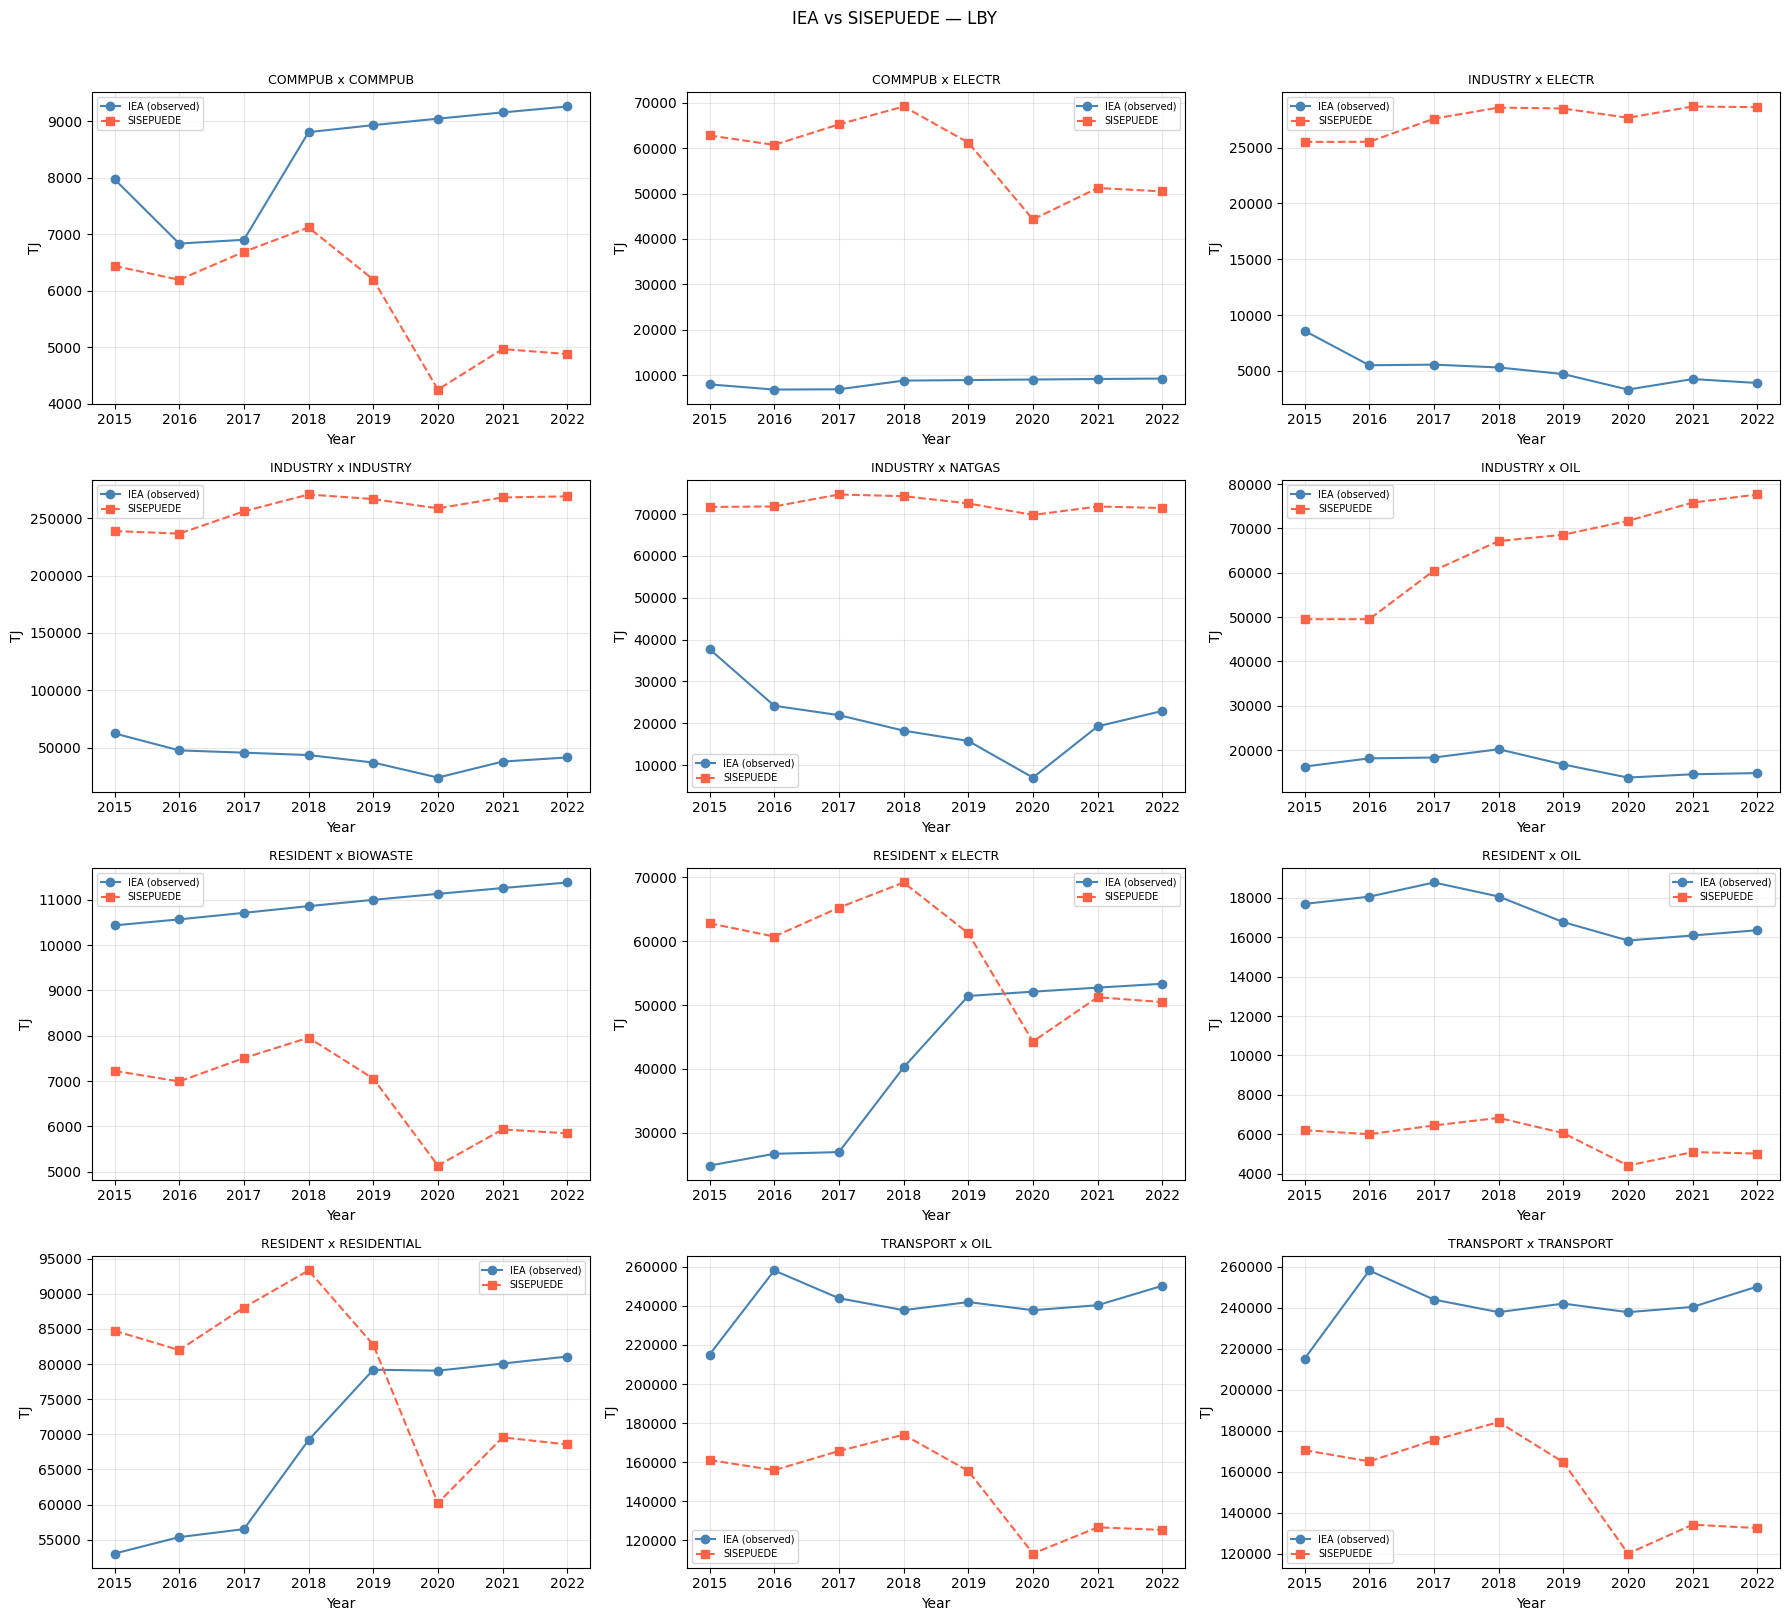

In [12]:
plot_condition = (df_comparison['year'] >= START_YEAR) & (df_comparison['year'] <= TRUE_DATA_LIMIT_YEAR)
df_comparison = df_comparison.loc[plot_condition]

# Final consumption by sector — primary calibration check
plot_comparison(
    df_comparison,
    balance_codes=["INDUSTRY", "TRANSPORT", "RESIDENT", "COMMPUB", "TFC"],
    country=ISO_COUNTRY,
)

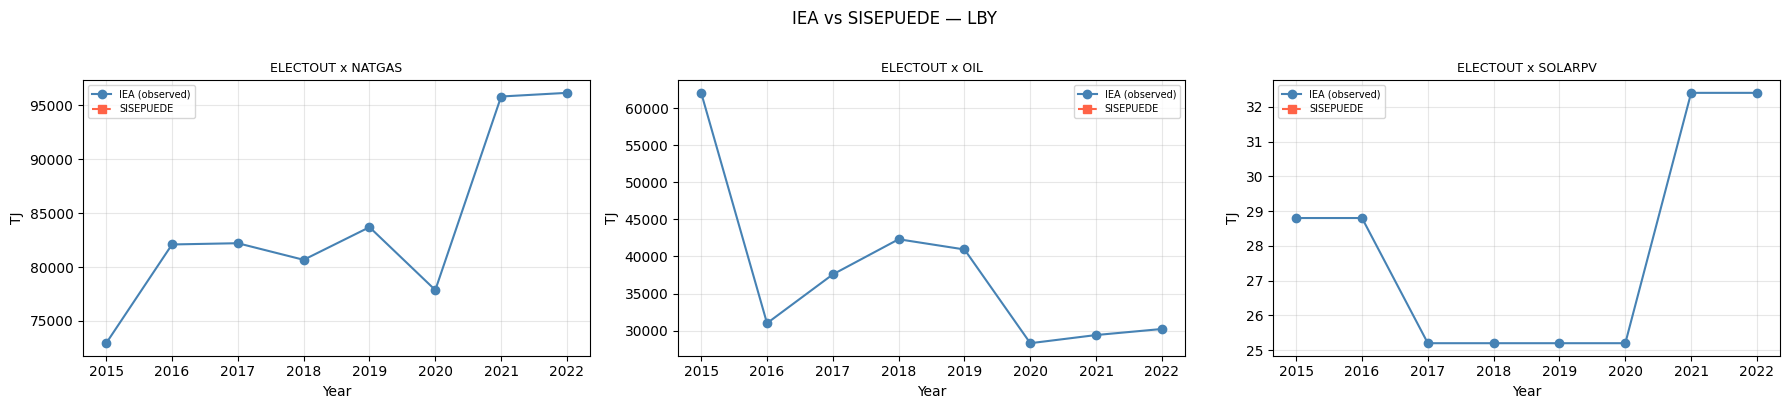

In [13]:
# Electricity generation by technology
plot_comparison(df_comparison, balance_codes=["ELECTOUT"], country=ISO_COUNTRY)

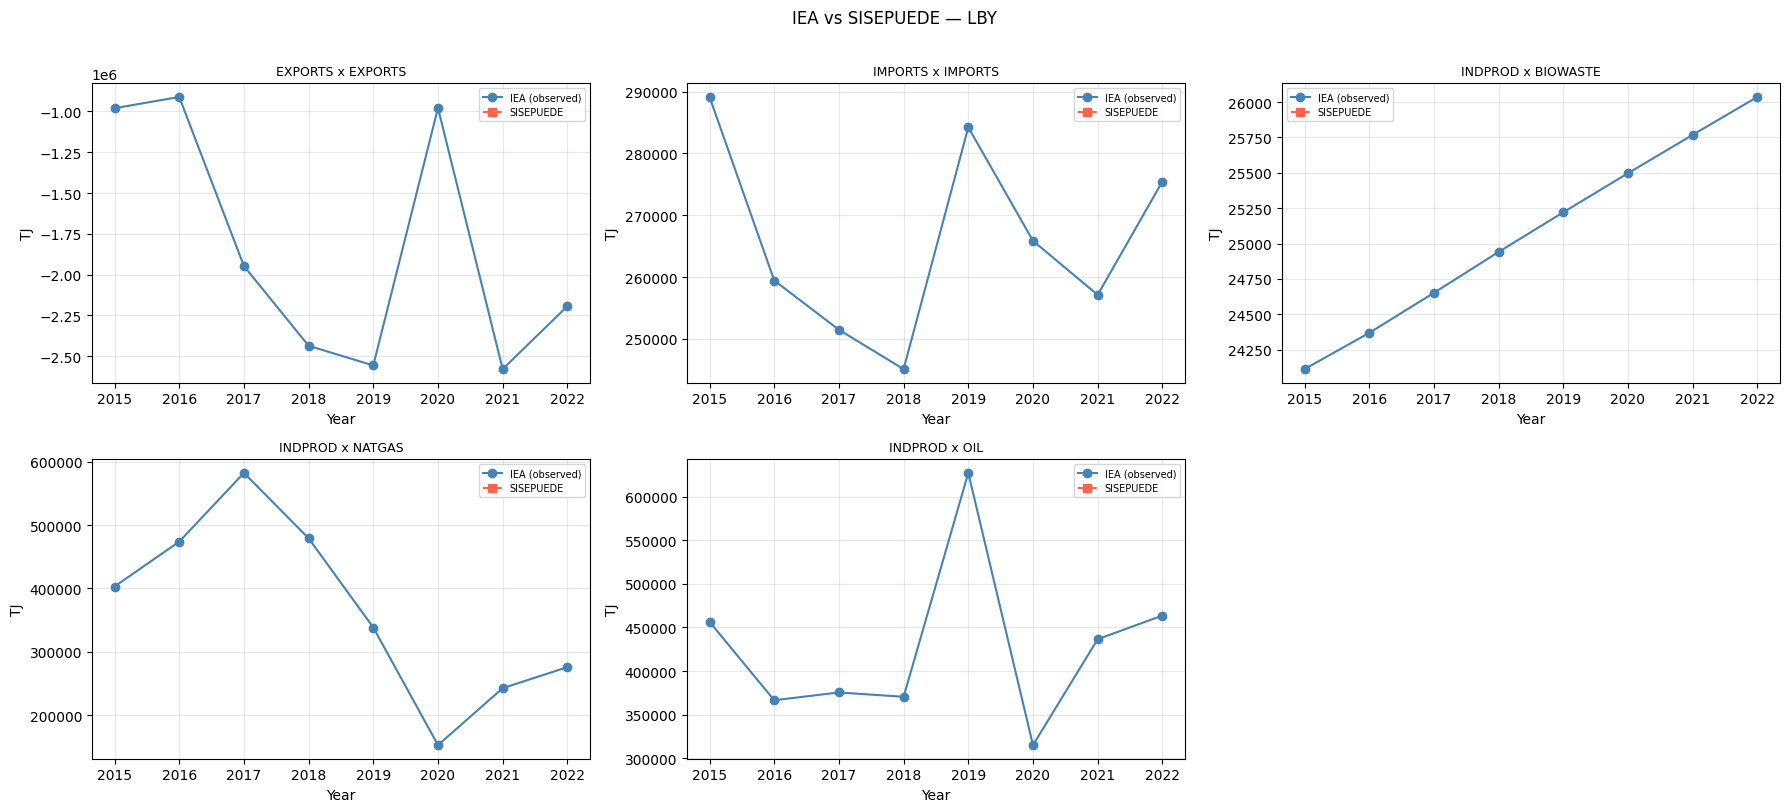

In [14]:
# Energy supply
plot_comparison(df_comparison, balance_codes=["INDPROD", "IMPORTS", "EXPORTS"], country=ISO_COUNTRY)

---
## 8. Export

In [15]:
PATH_OUTPUT = f"/Users/dianamendez/Documents/sisepuede/iea_vs_sisepuede_{ISO_COUNTRY}.csv"

df_comparison.to_csv(PATH_OUTPUT, index=False)
print(f"Saved to {PATH_OUTPUT}")

Saved to /Users/dianamendez/Documents/sisepuede/iea_vs_sisepuede_LBY.csv
